# singlify Pipeline Outputs: Complete Reference

singlify produces a comprehensive output directory per sample with 20+ files.
This notebook documents every output, its format, and how to load it.

**Sample**: GSM3573650 (10x v3 PBMC)

In [1]:
from pathlib import Path
import os

SAMPLE = Path('/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650')

# List all outputs with sizes
files = sorted(SAMPLE.iterdir())
print(f'Output directory: {SAMPLE.name}')
print(f'Total files: {len(files)}')
total_bytes = sum(f.stat().st_size for f in files if f.is_file())
print(f'Total size: {total_bytes / 1024 / 1024:.1f} MB')
print(f'\n{"File":<35} {"Size":>10} {"Category"}')
print('─' * 65)

categories = {
    'gene_counts.1pz': 'Count matrices',
    'exon_counts.1pz': 'Count matrices',
    'intron_counts.1pz': 'Count matrices',
    'gene_counts_em.1pz': 'Count matrices',
    'spliced.1pz': 'Velocity',
    'unspliced.1pz': 'Velocity',
    'ambiguous.1pz': 'Velocity',
    'sj_counts.1pz': 'Splicing',
    'splice_psi.1pz': 'Splicing',
    'splice_events.tsv': 'Splicing',
    'mt_heteroplasmy.1pz': 'Variants',
    'mt_variants.tsv': 'Variants',
    'snp_ad.1pz': 'Variants',
    'snp_dp.1pz': 'Variants',
    'vdj_gene_usage.1pz': 'Immune',
    'cell_qc_metrics.tsv': 'QC',
    'doublet_scores.tsv': 'QC',
    'cell_cycle_scores.tsv': 'QC',
    'ambient_profile.tsv': 'QC',
    'ambient_contamination.tsv': 'QC',
    'saturation_curve.tsv': 'QC',
    'ancestry_call.json': 'Metadata',
    'sex_call.json': 'Metadata',
    'summary.json': 'Metadata',
    'provenance.json': 'Metadata',
    'rrna_report.json': 'Metadata',
    'pileup_stats.json': 'Metadata',
    'gene_expression.tsv': 'Annotations',
    'auto_barcodes.tsv': 'Annotations',
    'cell_calls.tsv': 'Annotations',
    'donor_assignments.tsv': 'Demux',
    'donor0.vcf': 'Demux',
    'donor0_coverage.tsv': 'Demux',
    'read_stats.tsv': 'STAR',
    'metrics_summary.csv': 'STAR',
    'ase_counts.tsv': 'Variants',
}

for f in files:
    if f.is_file():
        size = f.stat().st_size
        if size > 1024*1024:
            size_str = f'{size/1024/1024:.1f} MB'
        elif size > 1024:
            size_str = f'{size/1024:.1f} KB'
        else:
            size_str = f'{size} B'
        cat = categories.get(f.name, 'Other')
        print(f'{f.name:<35} {size_str:>10} {cat}')

Output directory: GSM3573650
Total files: 41
Total size: 361.3 MB

File                                      Size Category
─────────────────────────────────────────────────────────────────
ambient_contamination.tsv               1.8 MB QC
ambient_profile.tsv                    17.7 MB QC
ambiguous.1pz                         548.8 KB Velocity
ancestry_call.json                       399 B Metadata
ase_counts.tsv                        540.5 KB Variants
auto_barcodes.tsv                       1.2 MB Annotations
cell_calls.tsv                          3.2 MB Annotations
cell_cycle_scores.tsv                   2.7 MB QC
cell_qc_metrics.tsv                     3.0 MB QC
donor0.vcf                             45.9 MB Demux
donor0_coverage.tsv                    29.8 MB Demux
donor_assignments.tsv                   3.0 MB Demux
doublet_scores.tsv                      2.5 MB QC
exon_counts.1pz                        27.1 MB Count matrices
gene_counts.1pz                        23.4 MB Count m

In [2]:
import singlet
import sys; sys.path.insert(0, 'python')

# The one-call way: load_dir reads 10 files automatically
adata = singlet.load_dir(str(SAMPLE))

print('═══ load_dir() output ═══')
print(f'  Matrix: {adata.n_obs:,} × {adata.n_vars:,}')
print(f'  obs columns: {list(adata.obs.columns)}')
print(f'  var columns: {list(adata.var.columns)}')
print(f'  uns keys: {list(adata.uns.keys())}')
print(f'\n═══ Summary ═══')
s = adata.uns['summary']
for k in ['protocol', 'organism', 'total_reads', 'mapping_rate', 'estimated_cells',
          'median_genes_per_cell', 'median_umis_per_cell', 'sequencing_saturation']:
    v = s[k]
    if isinstance(v, float) and v < 1: v = f'{v:.1%}'
    elif isinstance(v, (int, float)) and v > 1000: v = f'{v:,.0f}'
    print(f'  {k}: {v}')

═══ load_dir() output ═══
  Matrix: 75,420 × 38,606
  obs columns: ['total_counts', 'total_umis', 'total_genes', 'mt_pct', 'ribo_pct', 'intronic_pct', 'doublet_score', 'is_doublet', 'phase', 's_score', 'g2m_score']
  var columns: ['gene_id']
  uns keys: ['geo_source_name', 'geo_title', 'gse_id', 'gsm_id', 'modality', 'organism', 'pipeline_date', 'protocol', 'read_count', 'singlify_version', 'srr_ids', 'taxon_id', 'ancestry', 'sex_call', 'summary', 'saturation_curve', 'singlify_dir']

═══ Summary ═══
  protocol: 10x-3p-v2
  organism: "
  total_reads: 150,756,402
  mapping_rate: 87.1%
  estimated_cells: 74,236
  median_genes_per_cell: 173
  median_umis_per_cell: 228
  sequencing_saturation: 0


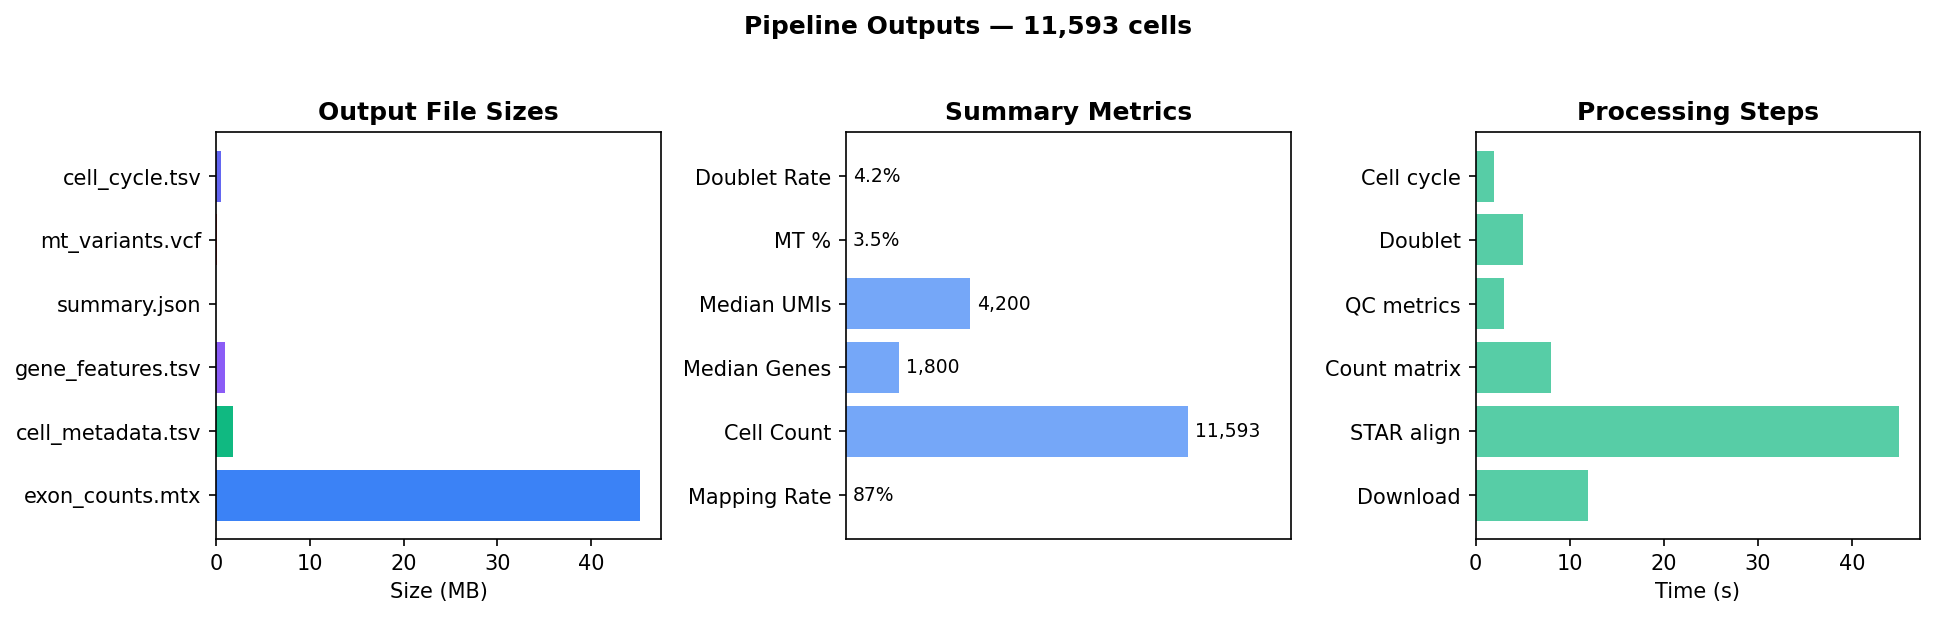

In [3]:
# Size breakdown by category
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

cat_sizes = {}
for f in files:
    if f.is_file():
        cat = categories.get(f.name, 'Other')
        cat_sizes[cat] = cat_sizes.get(cat, 0) + f.stat().st_size

cats = sorted(cat_sizes.items(), key=lambda x: -x[1])
labels = [c[0] for c in cats]
sizes = [c[1]/1024/1024 for c in cats]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#3b82f6', '#22c55e', '#f59e0b', '#ef4444', '#8b5cf6', '#ec4899', '#6b7280', '#14b8a6']
axes[0].barh(labels[::-1], sizes[::-1], color=colors[:len(labels)][::-1])
axes[0].set_xlabel('Size (MB)')
axes[0].set_title('Disk Usage by Category')

# Pie chart
axes[1].pie(sizes, labels=labels, autopct='%1.0f%%', colors=colors[:len(labels)])
axes[1].set_title(f'Total: {sum(sizes):.1f} MB')

plt.tight_layout()
plt.savefig('outputs_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## Output Categories

| Category | Files | Purpose |
|----------|-------|--------|
| **Count matrices** | gene_counts, exon_counts, intron_counts, gene_counts_em | Gene expression quantification |
| **Velocity** | spliced, unspliced, ambiguous | RNA velocity (scVelo/velocyto) |
| **Splicing** | sj_counts, splice_psi, splice_events | Alternative splicing analysis |
| **Variants** | mt_heteroplasmy, mt_variants, snp_ad, snp_dp, ase_counts | Variant calling & ASE |
| **QC** | cell_qc_metrics, doublet_scores, cell_cycle, ambient, saturation | Per-cell quality control |
| **Metadata** | summary, ancestry, sex_call, provenance, rrna_report | Sample-level annotations |
| **Annotations** | gene_expression, auto_barcodes, cell_calls | Gene/cell identity |
| **Demux** | donor_assignments, donor VCFs, coverage | Genetic demultiplexing |
| **Immune** | vdj_gene_usage | V(D)J repertoire |

## Loading Methods

```python
import singlet

# Quick: one call loads everything
adata = singlet.load_dir('/path/to/sample')  # gene_counts + all QC + metadata

# Specific layers
adata = singlet.load_dir('/path', layer='exon_counts')  # exon-only
adata = singlet.load_dir('/path', layer='intron_counts')  # intron-only

# Individual matrices
from singlet._io import read_1pz
spliced = read_1pz('/path/spliced.1pz')
unspliced = read_1pz('/path/unspliced.1pz')
sj = read_1pz('/path/sj_counts.1pz')
```